# Moving Average Crossover Backtest: AAPL

Tested a 20/50-day moving average crossover strategy against buy-and-hold on AAPL (2019-2026), including realistic transaction costs and actual historical risk-free rates for idle cash.

**Result (with transaction costs):**
- Buy & Hold: 31.06% CAGR, 0.94 Sharpe, -33.36% max drawdown
- Strategy: 18.81% CAGR, 0.78 Sharpe, -28.36% max drawdown


The strategy is simple: when a short-term average price crosses above a long-term average, that's a buy signal, and when it crosses below, that's a sell signal — one of the most common beginner strategies in trading.

**What I did:**
- Pulled AAPL price data and built the strategy as a reusable function rather than one-off code
- Used the actual historical 13-week T-bill rate for idle cash instead of a flat guess
- Charged a small transaction cost on every trade instead of assuming free trading
- Tracked how often the strategy actually traded, not just its returns

**Tools:** `yfinance`, `pandas`, `NumPy`, `Matplotlib`

## Getting the data

I pulled daily AAPL price data from 2019 to early 2026 using yfinance, with `auto_adjust=True` so prices are split and dividend adjusted. This range covers a bunch of different market conditions, specifically the COVID-19 crash, 2022 downturn and even a long recovery, so it's a normal stretch to actually test a strategy on.


In [18]:
import yfinance as yf
import pandas as pd

raw = yf.download("AAPL", start="2019-01-01", end="2026-01-01", auto_adjust=True)

# yfinance returns MultiIndex columns, need to flatten.
# data = yf.download("AAPL", start="2019-01-01", end="2026-01-01")

if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.droplevel(1)


data = raw.copy()
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2019-01-02,37.436913,37.657383,36.562151,36.718613,148158800
2019-01-03,33.707920,34.544750,33.662878,34.132260,365248800
2019-01-04,35.146885,35.215635,34.089588,34.262643,234428400
2019-01-07,35.068653,35.282012,34.587417,35.251192,219111200
2019-01-08,35.737175,35.990834,35.208527,35.455070,164101200


## Moving averages

I calculated a 20day and a 50day moving average from the closing price. These two lines are what the whole strategy is built on.

In [19]:
SHORT_WINDOW = 20
LONG_WINDOW = 50

data['SMA_short'] = data['Close'].rolling(window=SHORT_WINDOW).mean()
data['SMA_long'] = data['Close'].rolling(window=LONG_WINDOW).mean()
data.tail()

Price,Close,High,Low,Open,Volume,SMA_short,SMA_long
Date,,,,,,,
2025-12-24,273.066742,274.682340,271.461127,271.600731,17910600,276.399652,270.219039
2025-12-26,272.657806,274.622460,272.119264,273.415753,21521800,276.192714,270.703749
2025-12-29,273.016876,273.615223,271.610700,271.949773,23715200,275.938907,271.233300
2025-12-30,272.338684,273.335969,271.540868,272.069428,22139600,275.439267,271.652845
2025-12-31,271.122009,272.937076,271.012322,272.318764,27293600,274.724712,271.849788


## Building the signal

This is the actual strategy logic. If the 20day average is above the 50day average, the signal is 1, meaning I'd be holding the stock. If it's below, the signal is 0, meaning I'd be sitting out in cash.

During the first 49 days, `SMA_long` hasn't warmed up yet, so those rows are dropped below rather than silently treated as "sit out".

In [20]:
data['Signal'] = (data['SMA_short'] > data['SMA_long']).astype(int)
data['Daily_Return'] = data['Close'].pct_change()

# drop the warm-up period so both curves start from the start date
data = data.dropna(subset=['SMA_long']).copy()

# data.loc[data['SMA_short'] > data['SMA_long'], 'Signal'] = 1


data[[ 'Close', 'SMA_short', 'SMA_long', 'Signal']].tail(10)

Price,Close,SMA_short,SMA_long,Signal
Date,,,,
2025-12-17,271.102051,276.209666,267.996821,1
2025-12-18,271.451111,276.390674,268.283639,1
2025-12-19,272.927124,276.760667,268.680081,1
2025-12-22,270.234467,276.734740,269.197424,1
2025-12-23,271.620667,276.557222,269.694867,1
2025-12-24,273.066742,276.399652,270.219039,1
2025-12-26,272.657806,276.192714,270.703749,1
2025-12-29,273.016876,275.938907,271.233300,1
2025-12-30,272.338684,275.439267,271.652845,1


## Calculating returns

The strategy earns the day's return only when the previous day's signal was 1 — the signal from the close of day *t-1* determines the position held from close *t-1* to close *t*. This avoids look-ahead bias, since the position is based on information already known at the start of the period being measured.

When the strategy is out of the market (Signal = 0), cash earns the actual historical 13-week T-bill rate for that date, pulled from yfinance (`^IRX`), rather than a flat guess — this matters since T-bills have paid a meaningful yield for a lot of this period. If that download fails for any reason, this falls back to a flat 4% annual rate.

Every time the position changes (going from out to in, or in to out), a small transaction cost is charged, since real trading isn't free.

In [21]:
COST_BPS = 5  # basis points charged per position change, one-way

try:
    irx = yf.download("^IRX", start="2019-01-01", end="2026-01-01", auto_adjust=True)
    if isinstance(irx.columns, pd.MultiIndex):
        irx.columns = irx.columns.droplevel(1)
    rf_annual = irx['Close'].reindex(data.index).ffill() / 100
    rf_daily = rf_annual / 252
except Exception as e:
    print(f"T-bill download failed ({e}), falling back to flat 4% annual rate")
    rf_daily = pd.Series(0.04 / 252, index=data.index)

position = data['Signal'].shift(1)
turnover = position.diff().abs().fillna(0)

gross_strategy_return = data['Daily_Return'] * position + rf_daily * (1 - position)
transaction_cost = turnover * (COST_BPS / 1e4)
data['Strategy_Return'] = gross_strategy_return - transaction_cost

data[['Close', 'Signal', 'Daily_Return', 'Strategy_Return']].tail(10)

[*********************100%***********************]  1 of 1 completed


Price,Close,Signal,Daily_Return,Strategy_Return
Date,,,,
2025-12-17,271.102051,1,-0.010087,-0.010087
2025-12-18,271.451111,1,0.001288,0.001288
2025-12-19,272.927124,1,0.005437,0.005437
2025-12-22,270.234467,1,-0.009866,-0.009866
2025-12-23,271.620667,1,0.005130,0.005130
2025-12-24,273.066742,1,0.005324,0.005324
2025-12-26,272.657806,1,-0.001498,-0.001498
2025-12-29,273.016876,1,0.001317,0.001317
2025-12-30,272.338684,1,-0.002484,-0.002484


## Checking how often it actually trades

Before looking at returns, it's worth seeing how active this strategy actually is — how many times it flipped in and out of the market, how long it typically stayed in a position, and what fraction of the time it was invested at all.

In [22]:
round_trip_trades = turnover.sum() / 2
pct_days_in_market = position.mean() * 100

# average holding period: total days in market divided by number of times it entered
entries = ((position == 1) & (position.shift(1) == 0)).sum()
avg_holding_days = position.sum() / entries if entries > 0 else float('nan')

print(f"Round-trip trades: {round_trip_trades:.0f}")
print(f"Average holding period: {avg_holding_days:.1f} trading days")
print(f"Percent of days in market: {pct_days_in_market:.1f}%")

Round-trip trades: 18
Average holding period: 61.8 trading days
Percent of days in market: 65.0%


## Adding it all up

This compounds the daily returns over time, so I can see how $1 would have grown if I just held the stock versus if I followed the strategy the whole way through.

In [23]:
data['Cumulative_Market_Return'] = (1 + data['Daily_Return']).cumprod()
data['Cumulative_Strategy_Return'] = (1 + data['Strategy_Return']).cumprod()
data[['Cumulative_Market_Return', 'Cumulative_Strategy_Return']].tail(10)

Price,Cumulative_Market_Return,Cumulative_Strategy_Return
Date,,
2025-12-17,6.266606,3.217947
2025-12-18,6.274674,3.222091
2025-12-19,6.308793,3.239611
2025-12-22,6.246551,3.207649
2025-12-23,6.278594,3.224103
2025-12-24,6.312020,3.241268
2025-12-26,6.302567,3.236414
2025-12-29,6.310867,3.240676
2025-12-30,6.295191,3.232626


## Plotting it out

This graph shows both return curves. The strategy line is flatter as it spends real time out of the market, which caps both its losses and its gains. The gaps between the two lines widen sharply during the strongest recovery stretches (2023 and 2024-25), since that's exactly when the strategy tends to be lagging back into a position rather than already in it.

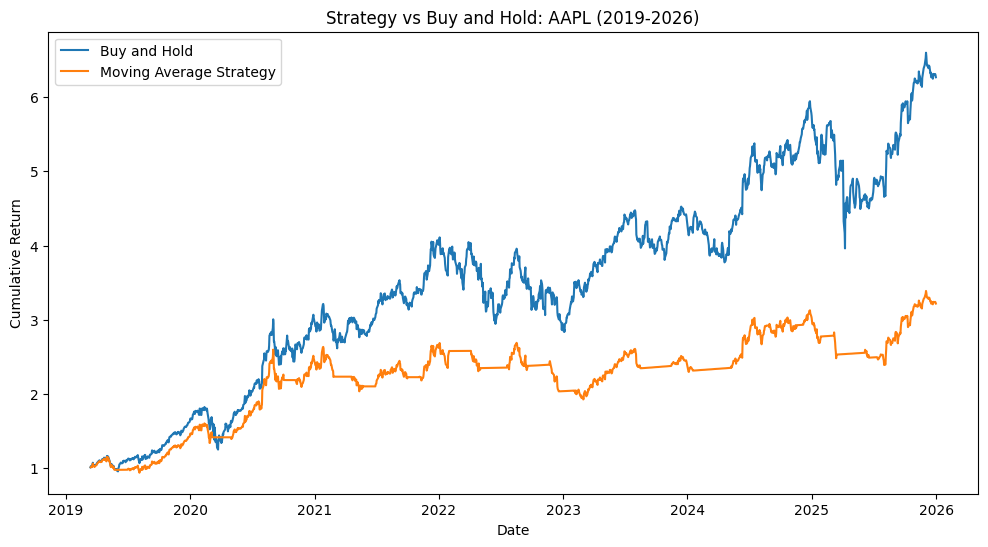

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(data['Cumulative_Market_Return'], label='Buy and Hold')
plt.plot(data['Cumulative_Strategy_Return'], label='Moving Average Strategy')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.title('Strategy vs Buy and Hold: AAPL (2019-2026)')
plt.legend()
plt.show()

## Seeing the whipsaws directly

The graph shows overall performance, but not *why* the strategy underperforms. This next plot overlays both moving averages on price itself, with the periods the strategy was actually in the market shaded, this makes the whipsaw effect visible directly, rather than just inferred from the return gap.

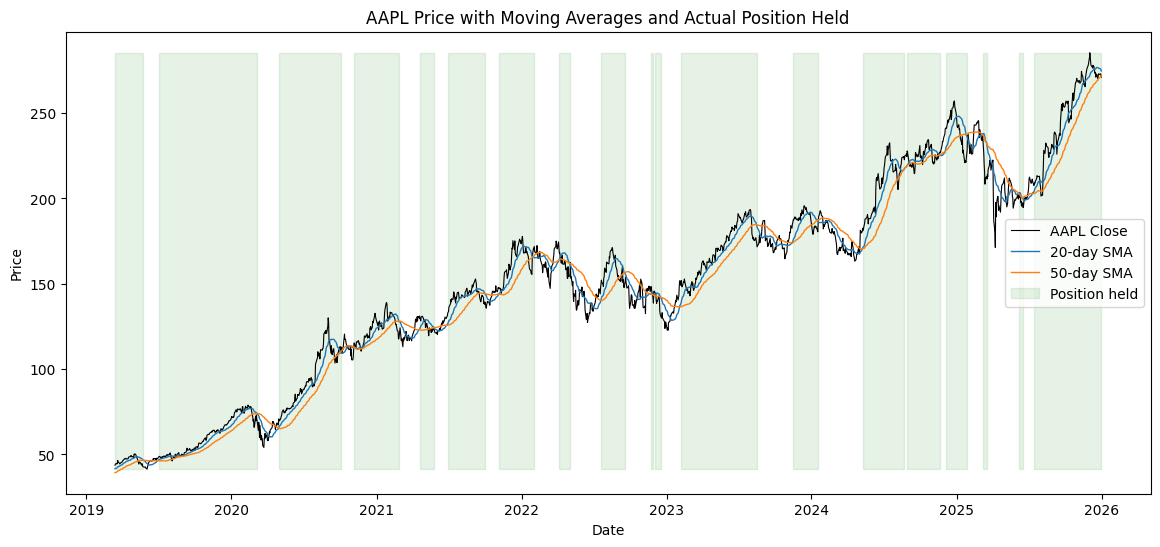

In [25]:
fig, ax = plt.subplots(figsize=(14,6))
ax.plot(data['Close'], label='AAPL Close', color='black', linewidth=0.8)
ax.plot(data['SMA_short'], label=f'{SHORT_WINDOW}-day SMA', linewidth=1)
ax.plot(data['SMA_long'], label=f'{LONG_WINDOW}-day SMA', linewidth=1)
ax.fill_between(data.index, data['Close'].min(), data['Close'].max(),
                where=position==1, alpha=0.1, color='green', label='Position held')
ax.set_xlabel('Date')
ax.set_ylabel('Price')
ax.set_title('AAPL Price with Moving Averages and Actual Position Held')
ax.legend()
plt.show()

## Checking the risk side

Returns aren't the whole story, a strategy that makes less money but also loses less during a crash can still be worth something. Max drawdown shows the biggest drop each approach took from its peak.

=== With transaction costs ===
Buy and Hold  -  CAGR: 31.06%, Max Drawdown: -33.36%, Sharpe: 0.94
Strategy      -  CAGR: 18.81%, Max Drawdown: -28.36%, Sharpe: 0.78

=== Strategy without transaction costs (for comparison) ===
Strategy (no costs) - CAGR: 19.12%, Max Drawdown: -28.15%, Sharpe: 0.79


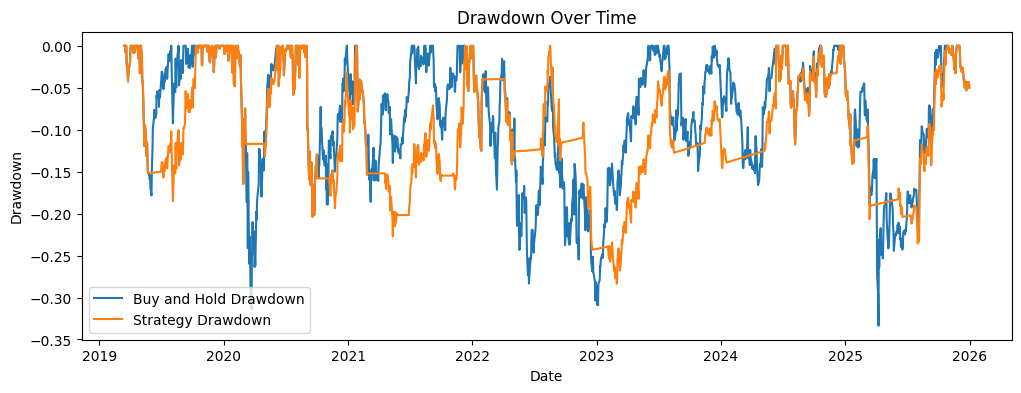

In [26]:
def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak
    return drawdown, drawdown.min()

def cagr(cumulative_returns, periods_per_year=252):
    n_returns = cumulative_returns.count() - 1  # number of actual return periods, not row count
    n_years = n_returns / periods_per_year
    return cumulative_returns.iloc[-1] ** (1 / n_years) - 1

def sharpe(daily_returns, rf_daily, periods_per_year=252):
    excess = daily_returns - rf_daily
    return (excess.mean() / excess.std()) * (periods_per_year ** 0.5)

def summarize(equity, returns, rf_daily_series):
    dd_series, dd = max_drawdown(equity)
    return {
        "CAGR": cagr(equity),
        "Sharpe": sharpe(returns, rf_daily_series),
        "MaxDrawdown": dd,
        "FinalMultiple": equity.iloc[-1],
        "DrawdownSeries": dd_series,
    }

# with transaction costs (the realistic version)
market_summary = summarize(data['Cumulative_Market_Return'], data['Daily_Return'].dropna(), rf_daily)
strategy_summary = summarize(data['Cumulative_Strategy_Return'], data['Strategy_Return'].dropna(), rf_daily)

# without transaction costs, for comparison
gross_cumulative = (1 + gross_strategy_return).cumprod()
strategy_summary_no_costs = summarize(gross_cumulative, gross_strategy_return.dropna(), rf_daily)

print("=== With transaction costs ===")
print(f"Buy and Hold  -  CAGR: {market_summary['CAGR']:.2%}, Max Drawdown: {market_summary['MaxDrawdown']:.2%}, Sharpe: {market_summary['Sharpe']:.2f}")
print(f"Strategy      -  CAGR: {strategy_summary['CAGR']:.2%}, Max Drawdown: {strategy_summary['MaxDrawdown']:.2%}, Sharpe: {strategy_summary['Sharpe']:.2f}")
print()
print("=== Strategy without transaction costs (for comparison) ===")
print(f"Strategy (no costs) - CAGR: {strategy_summary_no_costs['CAGR']:.2%}, Max Drawdown: {strategy_summary_no_costs['MaxDrawdown']:.2%}, Sharpe: {strategy_summary_no_costs['Sharpe']:.2f}")

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(market_summary['DrawdownSeries'], label='Buy and Hold Drawdown')
ax.plot(strategy_summary['DrawdownSeries'], label='Strategy Drawdown')
ax.set_xlabel('Date')
ax.set_ylabel('Drawdown')
ax.set_title('Drawdown Over Time')
ax.legend()
plt.show()

## Sanity check: does the cost drag reconcile?

Comparing the two CAGR figures suggested the transaction costs were roughly double what the trade count implied. Rather than trust that, here's a direct check: 36 one-way position changes at 5 bps should cost about 1.80% cumulatively, and comparing final equity with and without costs gives the actual number below. It ties out.

In [28]:
print("Total turnover (one-way position changes):", turnover.sum())
print()
print("Final multiple with costs:", strategy_summary['FinalMultiple'])
print("Final multiple without costs:", strategy_summary_no_costs['FinalMultiple'])
implied_drag = strategy_summary_no_costs['FinalMultiple'] / strategy_summary['FinalMultiple'] - 1
expected_drag = turnover.sum() * (COST_BPS / 1e4)
print(f"Implied cumulative cost drag: {implied_drag:.2%}")
print(f"Expected cumulative cost drag (trades x cost): {expected_drag:.2%}")

Total turnover (one-way position changes): 36.0

Final multiple with costs: 3.2181842480977476
Final multiple without costs: 3.2766372264020323
Implied cumulative cost drag: 1.82%
Expected cumulative cost drag (trades x cost): 1.80%


## Assumptions and limitations

- Long/flat only — no short positions
- Full capital committed on every trade, no partial position sizing
- Fills happen at the closing price of the signal day, not the next day's open
- Single ticker, single parameter pair (20/50) — a multi-asset, multi-parameter check is a separate follow-up
- Cash return while out of the market uses the actual historical 13-week T-bill rate where available, falling back to a flat 4% estimate if that data can't be pulled

## What I found

Buy and hold clearly won on returns, even after accounting for transaction costs. Looking at the risk-adjusted numbers tells the same story:

| | CAGR | Max Drawdown | Sharpe |
|---|---|---|---|
| Buy & Hold | 31.06% | -33.36% | 0.94 |
| Strategy | 18.81% | -28.36% | 0.78 |

The strategy made 18 round-trip trades over this period, spending 65% of the time actually in the market, with an average holding period of about 62 trading days per position. Transaction costs cost the strategy about 1.8% cumulatively over the full period (verified directly by comparing final returns with and without costs) — a real but fairly small drag. The underperformance against buy-and-hold isn't really about trading fees, it's about missing time in the market during recoveries.

This tracks with what's expected: simple moving average strategies tend to get whipsawed out of the market during choppy stretches and miss the sharp early days of recoveries, which adds up significantly over a long bull run like AAPL's. It's also worth noting AAPL was not a neutral pick — it grew substantially over this window, which stacks the deck toward buy-and-hold before the strategy is even tested.

## Where this could go further

This strategy is about as simple as trend following gets, and that's kind of the point. A few honest directions this could go:

- **Parameter and universe robustness testing:** right now this is one asset and one parameter pair — a sample size of one. A planned follow-up will run this same strategy across a bunch of different stocks and window combinations to check whether this result actually holds up generally, or if it's specific to AAPL's exact price path over this exact period.

- **Walk-forward validation:** the 20/50 windows were picked once and tested on the full history. A more honest test would pick parameters using only past data at each point in time and test forward from there, so the result isn't quietly benefiting from hindsight.

- **Multiple-testing correction:** once a parameter sweep is run, some combinations will look good just by chance. Worth being careful about treating any single good-looking result as a real finding rather than noise.

- **Multiple signals combined:** adding something like RSI sounds like it should help, but it also adds more free parameters, and technical indicators tend to be pretty correlated with each other anyway. The real question isn't whether adding RSI seems reasonable, it's whether it adds anything once you account for the extra parameters it introduces.

- **Position sizing:** right now the strategy is either fully in or fully out. A more advanced version might scale position size based on signal strength or volatility, rather than a hard on/off switch.

- **Different asset classes:** trend following strategies like this tend to perform better in commodities or currency markets than in a single high-growth stock like AAPL, since those markets often have longer, cleaner trends.

- **Machine learning based signals:** with about 1,700 daily observations on a single stock, there isn't a lot of real signal to learn from compared to noise. A flexible model would probably overfit before it actually learned anything useful. If ML shows up here at all, it'd make more sense as a way to combine a few existing signals together under strict walk-forward validation, not as something trying to find patterns directly in raw price data.

This project started as a simple first step into backtesting, and turned into a decent lesson in why single-asset, single-parameter results shouldn't be taken at face value.